# Lesson 6: Flutter Shutter Photography

**Description:** 

**Requirement(s):** scikit-image

**Author:** Matthew O'Toole

---

In [24]:
import bpy
import bmesh
import numpy as np
import matplotlib.pyplot as plt
import import_ipynb
import itertools

from skimage import restoration
from skimage.transform import resize

from L001_hello_world import render, clear_scene
from L004_pixel_measurement_model import add_sensor_noise, get_sensor_noise_statistics

# Clear scene
if __name__ == '__main__':
    clear_scene()

In [25]:
if __name__ == '__main__':
    # Set render engine and resolution for ray tracing
    bpy.context.scene.render.engine = 'CYCLES'
    bpy.context.scene.render.resolution_x = 1024
    bpy.context.scene.render.resolution_y = 1024
    bpy.context.scene.render.image_settings.file_format = 'HDR'

    # Do not reduce number of samples per pixel based on render noise
    bpy.context.scene.cycles.use_adaptive_sampling = False 

    # Set number of samples to render at each pixel
    bpy.context.scene.cycles.samples = 100

    # Do not denoise the rendered image
    bpy.context.scene.cycles.use_denoising = False

    # Set film filter to box
    bpy.context.scene.cycles.pixel_filter_type = 'BOX'

    # Change camera exposure (in EV steps, default is 0.0)
    bpy.context.scene.cycles.film_exposure = 0.01


    # Create camera
    bpy.ops.object.camera_add(location=(0, 0, 4),
                              rotation=(0, 0, 0))
    cam = bpy.context.active_object
    bpy.context.scene.camera = cam


    # Add plane to scene
    bpy.ops.mesh.primitive_plane_add(location=(0, 0, 0), 
                                     rotation=(0, 0, 0))
    plane = bpy.context.active_object
    plane.scale = (1,621/721,1)


    # Add texture material
    texture_material = bpy.data.materials.new(name='Texture Material')

    nodes = texture_material.node_tree.nodes
    bsdf = nodes['Principled BSDF']
    bsdf.inputs['Emission Strength'].default_value = 2.0

    image_toy = bpy.data.images.load('./textures/toytrain.png')
    image_line = bpy.data.images.load('./textures/line.png')

    texture = nodes.new(type='ShaderNodeTexImage')
    texture.image = image_line
    texture.location = (-600, 0)

    links = texture_material.node_tree.links
    links.new(texture.outputs['Color'], bsdf.inputs['Emission Color'])

    plane.data.materials.append(texture_material)

In [26]:
if __name__ == '__main__':
    #bpy.context.preferences.edit.keyframe_new_interpolation_type = 'LINEAR'

    #plane.animation_data_create()
    #plane.animation_data.action = bpy.data.actions.new(name="Linear Motion")
    #action = plane.animation_data.action

    #fcu = action.fcurves.new(data_path="location", index=0)
    #kp = fcu.keyframe_points.insert(1, -1)
    #kp = fcu.keyframe_points.insert(2, 1)

    #fcu.update()

    bpy.context.scene.frame_set(1)
    plane.location = (0.2, 0, 0)
    plane.keyframe_insert(data_path="location", frame=1)

    bpy.context.scene.frame_set(2)
    plane.location = (-0.2, 0, 0)
    plane.keyframe_insert(data_path="location", frame=2)

    action = plane.animation_data.action

    for layer in action.layers:
        for strip in layer.strips:
            for channelbag in strip.channelbags:
                for fcurve in channelbag.fcurves:
                    for kp in fcurve.keyframe_points:
                        kp.interpolation = 'LINEAR'

    bpy.context.scene.frame_set(1)

    bpy.context.scene.render.use_motion_blur = True
    bpy.context.scene.render.motion_blur_position = 'START'
    bpy.context.scene.render.motion_blur_shutter = 1

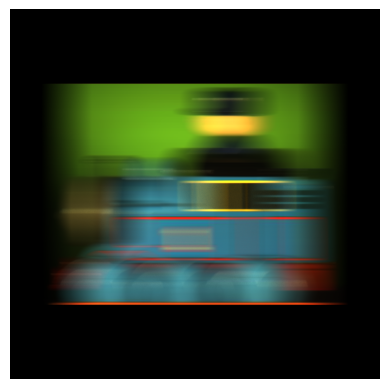

In [27]:
if __name__ == '__main__':
    texture.image = image_toy
    img = render()
    plt.imshow(np.clip(img, 0, 1), origin='lower')
    plt.axis('off')

In [46]:
def set_shutter_curve(curve_mapping, code):
    # Assumes only first curve in the mapping
    curve = curve_mapping.curves[0]
    pts = curve.points
    
    # Ensure correct number of points
    # Remove extra
    while len(pts) > len(code):
        pts.remove(pts[-1])

    # Add new if needed
    while len(pts) < 2*len(code):
        pts.new(0.0, 0.0)

    eps = 1e-4
    for k in range(len(code)):
        pts[2*k].location.x = k / len(code)
        pts[2*k].location.y = code[k]

        pts[2*k+1].location.x = (k+1) / len(code) - eps
        pts[2*k+1].location.y = code[k]

    curve_mapping.update()

if __name__ == '__main__':
    code = '11111111'
    #code = '1010000111000001010000110011110111010111001001100111'
    kernel = np.array(list(map(int, code))) 
    
    # Apply custom curve
    set_shutter_curve(bpy.context.scene.render.motion_blur_shutter_curve, kernel)

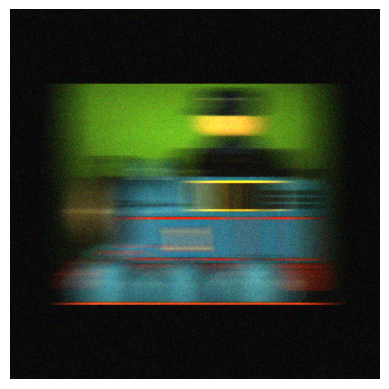

In [47]:
if __name__ == '__main__':
    texture.image = image_toy
    img = render()
    noise = np.random.normal(0, 0.1, img.shape)
    img = img + noise
    plt.imshow(np.clip(img, 0, 1), origin='lower')
    plt.axis('off')

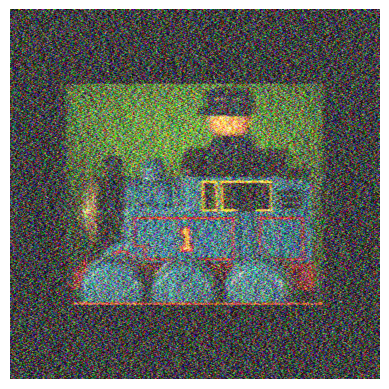

In [48]:
if __name__ == '__main__':
    texture.image = image_line
    kernel = render()
    tmp = np.mean(kernel, axis=2)
    tmp = np.mean(tmp, axis=0)
    tmp = tmp / np.sum(tmp.flatten())
    kernel[:,:,:] = 0
    kernel[0,:,0] = np.fft.fftshift(tmp)

    tmp = np.fft.fftn(img) * np.conj(np.fft.fftn(kernel)) / (np.abs(np.fft.fftn(kernel))**2 + 1e-3)
    result = np.fft.ifftn(tmp).real

    #result = restoration.richardson_lucy(img, kernel[np.newaxis,:,np.newaxis], num_iter=30)
    #result = restoration.richardson_lucy(img, kernel[:1,:,:1], num_iter=30)
    plt.imshow(np.clip(1*result[:,:], 0, 1), origin='lower')
    plt.axis('off')